# Vanishing/Exploding Gradients & Gradient Clipping

Why deep networks are hard to train, implemented from scratch: we deliberately induce
vanishing and exploding gradients in deep MLPs, validate gradient clipping against
PyTorch, and show clipping rescuing training runs that otherwise diverge to `NaN`.

We answer four concrete questions with numbers:
1. How small can a gradient reaching the first layer of a deep sigmoid network get,
   relative to the last layer, purely from repeated multiplication by small factors?
2. How large can gradients grow in a deep ReLU network with a slightly-too-large weight
   scale — and how fast does that growth compound with depth?
3. Does our from-scratch `clip_grad_norm` match PyTorch's `torch.nn.utils.clip_grad_norm_`?
4. Can gradient clipping turn a training run that diverges to `NaN` into one that
   converges — across a range of learning rates?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_moons

np.random.seed(0)
plt.rcParams['figure.dpi'] = 100

## 1. A Depth-Configurable MLP With Per-Layer Gradient Tracking

Topic 06 showed that *initialization scale* determines whether **activations** vanish or
explode with depth. Here we track the same phenomenon in the **backward pass** directly:
the gradient reaching layer $i$ passes through $(\text{depth} - i)$ repeated multiplications
by $W^\top$ and an activation derivative. Small factors compound to (near) zero; large
factors compound to enormous values — exactly like Topic 10's BPTT analysis, but now across
**network depth** rather than **time**.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


class DeepMLP:
    """Configurable-depth MLP; every hidden layer has the same width and activation."""

    def __init__(self, depth, width=32, in_dim=2, out_dim=1, activation='tanh',
                 weight_scale=1.0, seed=0):
        rng = np.random.RandomState(seed)
        self.depth = depth
        self.activation = activation
        dims = [in_dim] + [width] * (depth - 1) + [out_dim]
        self.Ws, self.bs = [], []
        for i in range(depth):
            fan_in = dims[i]
            std = weight_scale / np.sqrt(fan_in)
            self.Ws.append(rng.randn(dims[i], dims[i + 1]) * std)
            self.bs.append(np.zeros(dims[i + 1]))

    def _act(self, z):
        if self.activation == 'tanh':
            return np.tanh(z)
        if self.activation == 'sigmoid':
            return sigmoid(z)
        if self.activation == 'relu':
            return np.maximum(0, z)
        raise ValueError(self.activation)

    def _dact(self, z, a):
        if self.activation == 'tanh':
            return 1 - a ** 2
        if self.activation == 'sigmoid':
            return a * (1 - a)
        if self.activation == 'relu':
            return (z > 0).astype(z.dtype)
        raise ValueError(self.activation)

    def forward(self, X):
        self.zs, self.as_ = [], [X]
        a = X
        for i in range(self.depth):
            z = a @ self.Ws[i] + self.bs[i]
            a = self._act(z) if i < self.depth - 1 else z  # linear output layer
            self.zs.append(z)
            self.as_.append(a)
        return a

    def loss_and_grads(self, X, y):
        n = X.shape[0]
        y = y.reshape(-1, 1)
        logits = self.forward(X)
        p = sigmoid(logits)
        p_clip = np.clip(p, 1e-12, 1 - 1e-12)
        loss = -np.mean(y * np.log(p_clip) + (1 - y) * np.log(1 - p_clip))
        gWs, gbs = [None] * self.depth, [None] * self.depth
        dz = (p - y) / n
        layer_norms = []
        for i in reversed(range(self.depth)):
            a_prev = self.as_[i]
            gWs[i] = a_prev.T @ dz
            gbs[i] = dz.sum(axis=0)
            layer_norms.append((i, np.linalg.norm(gWs[i])))
            if i > 0:
                da_prev = dz @ self.Ws[i].T
                dz = da_prev * self._dact(self.zs[i - 1], self.as_[i])
        layer_norms.reverse()
        return loss, gWs, gbs, layer_norms

    def apply_grads(self, gWs, gbs, lr):
        for i in range(self.depth):
            self.Ws[i] -= lr * gWs[i]
            self.bs[i] -= lr * gbs[i]


def global_grad_norm(gWs, gbs):
    total = sum(np.sum(g ** 2) for g in gWs + gbs)
    return np.sqrt(total)


X, y = make_moons(n_samples=200, noise=0.2, random_state=0)
print(f'DeepMLP defined. Data: {X.shape[0]} samples, {X.shape[1]} features.')

DeepMLP defined. Data: 200 samples, 2 features.


## 2. Vanishing Gradients: Sigmoid, Slightly-Too-Small Weight Scale

Use `sigmoid` activations (max derivative $0.25$ at $z=0$) with weight scale $0.5\times$ the
usual $1/\sqrt{\text{fan\_in}}$ — a small, easy-to-make mismatch, not an extreme one. We
measure the gradient norm reaching **layer 0** (input layer) vs the **last hidden layer**
after a single backward pass, across increasing depth.

 depth     layer0 norm    layerLast norm    ratio (L0/Llast)
     5       5.468e-05         1.346e-02           4.061e-03
    10       8.285e-10         3.655e-01           2.267e-09
    20       1.114e-18         3.158e-01           3.528e-18
    40       7.723e-37         9.402e-02           8.215e-36
    60       3.497e-55         2.831e-01           1.235e-54
    80       5.479e-74         3.354e-01           1.634e-73


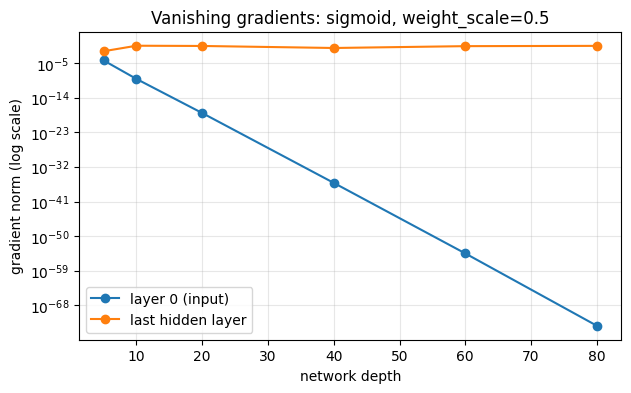

In [3]:
print(f"{'depth':>6}  {'layer0 norm':>14}  {'layerLast norm':>16}  {'ratio (L0/Llast)':>18}")
depths = [5, 10, 20, 40, 60, 80]
vanish_records = []
for depth in depths:
    model = DeepMLP(depth=depth, width=32, activation='sigmoid', weight_scale=0.5, seed=0)
    _, gWs, gbs, layer_norms = model.loss_and_grads(X, y)
    l0, lL = layer_norms[0][1], layer_norms[-1][1]
    vanish_records.append((depth, l0, lL))
    print(f'{depth:>6}  {l0:>14.3e}  {lL:>16.3e}  {l0 / (lL + 1e-300):>18.3e}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(depths, [r[1] for r in vanish_records], '-o', label='layer 0 (input)')
ax.semilogy(depths, [r[2] for r in vanish_records], '-o', label='last hidden layer')
ax.set_xlabel('network depth'); ax.set_ylabel('gradient norm (log scale)')
ax.set_title('Vanishing gradients: sigmoid, weight_scale=0.5')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.savefig('vanishing_gradients.png', dpi=100, bbox_inches='tight')
plt.show()

At depth 80, the gradient reaching layer 0 is on the order of $10^{-74}$ while the last
hidden layer's gradient stays near $0.3$ — the input layer receives **no usable learning
signal whatsoever**. This is the same mechanism as Topic 10's BPTT vanishing gradients,
but compounding across **layers** instead of **timesteps**.

## 3. Exploding Gradients: ReLU, Slightly-Too-Large Weight Scale

ReLU does not saturate, so a weight scale above the He-optimal $\sqrt{2/\text{fan\_in}}$
(i.e. `weight_scale` $> 1.0$ in our parameterization) lets both activations and gradients
grow **without bound** as depth increases — unlike sigmoid/tanh, where saturation caps how
large the forward signal (and hence some backward terms) can get.

--- Weight-scale sweep at fixed depth=20 ---
  scale        loss   total grad norm
    1.4      0.6965         5.783e-01
    2.0     13.4023         1.167e+03
    3.0     13.8155         2.583e+06
    4.0     13.8155         6.108e+08

--- Depth sweep at fixed weight_scale=2.0 ---
 depth   total grad norm
    10         3.037e+01
    15         1.556e+02
    20         1.167e+03
    25         6.820e+03
    30         7.734e+03


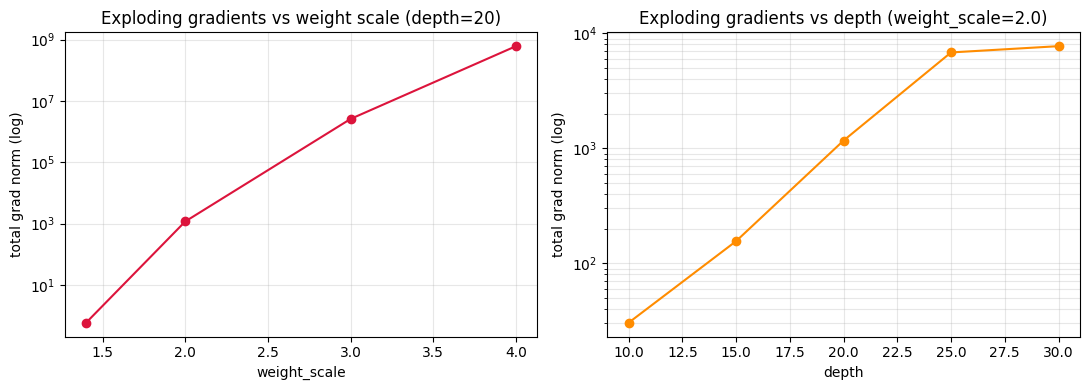

In [4]:
print('--- Weight-scale sweep at fixed depth=20 ---')
print(f"{'scale':>7}  {'loss':>10}  {'total grad norm':>16}")
scales = [1.4, 2.0, 3.0, 4.0]
scale_norms = []
with np.errstate(over='ignore', invalid='ignore'):
    for scale in scales:
        model = DeepMLP(depth=20, width=32, activation='relu', weight_scale=scale, seed=0)
        loss, gWs, gbs, _ = model.loss_and_grads(X, y)
        total = global_grad_norm(gWs, gbs)
        scale_norms.append(total)
        print(f'{scale:>7.1f}  {loss:>10.4f}  {total:>16.3e}')

print('\n--- Depth sweep at fixed weight_scale=2.0 ---')
print(f"{'depth':>6}  {'total grad norm':>16}")
depths2 = [10, 15, 20, 25, 30]
depth_norms = []
with np.errstate(over='ignore', invalid='ignore'):
    for depth in depths2:
        model = DeepMLP(depth=depth, width=32, activation='relu', weight_scale=2.0, seed=0)
        loss, gWs, gbs, _ = model.loss_and_grads(X, y)
        total = global_grad_norm(gWs, gbs)
        depth_norms.append(total)
        print(f'{depth:>6}  {total:>16.3e}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(scales, scale_norms, '-o', color='crimson')
axes[0].set_xlabel('weight_scale'); axes[0].set_ylabel('total grad norm (log)')
axes[0].set_title('Exploding gradients vs weight scale (depth=20)')
axes[0].grid(alpha=0.3, which='both')
axes[1].semilogy(depths2, depth_norms, '-o', color='darkorange')
axes[1].set_xlabel('depth'); axes[1].set_ylabel('total grad norm (log)')
axes[1].set_title('Exploding gradients vs depth (weight_scale=2.0)')
axes[1].grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('exploding_gradients.png', dpi=100, bbox_inches='tight')
plt.show()

Going from `weight_scale=1.4` to `4.0` at fixed depth 20, the total gradient norm grows
from $\approx 0.6$ to $\approx 6 \times 10^8$ — **9 orders of magnitude** from a
roughly 3× change in initialization scale. Depth compounds the same effect: at fixed
`weight_scale=2.0`, going from depth 10 to 30 grows the gradient norm from $\approx 30$ to
$\approx 7700$.

## 4. Gradient Clipping From Scratch

Two standard fixes, both applied **after** computing the full backward pass and **before**
the optimizer step:

**Clip by global norm** (preserves gradient *direction*, rescales *magnitude*):

$$g \leftarrow g \cdot \min\!\left(1,\ \frac{\text{max\_norm}}{\|g\|_2}\right)$$

where $\|g\|_2$ is computed over **all** parameters jointly (one scalar norm, not
per-tensor).

**Clip by value** (independent per element, does *not* preserve direction):

$$g_i \leftarrow \text{clip}(g_i,\ -c,\ c)$$

In [5]:
def clip_grad_norm(gWs, gbs, max_norm):
    total_norm = global_grad_norm(gWs, gbs)
    clip_coef = max_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        gWs = [g * clip_coef for g in gWs]
        gbs = [g * clip_coef for g in gbs]
    return gWs, gbs, total_norm


def clip_grad_value(gWs, gbs, clip_val):
    gWs = [np.clip(g, -clip_val, clip_val) for g in gWs]
    gbs = [np.clip(g, -clip_val, clip_val) for g in gbs]
    return gWs, gbs


print('clip_grad_norm and clip_grad_value defined.')

clip_grad_norm and clip_grad_value defined.


## 5. Validate `clip_grad_norm` Against PyTorch

Generate random "gradients" with a large norm, clip both with our implementation and
`torch.nn.utils.clip_grad_norm_`, and compare element-wise.

In [6]:
rng = np.random.RandomState(0)
raw_grads_W = [rng.randn(20, 20) * 5 for _ in range(4)]
raw_grads_b = [rng.randn(20) * 5 for _ in range(4)]
max_norm = 1.0

np_clip_W, np_clip_b, total_norm = clip_grad_norm(raw_grads_W, raw_grads_b, max_norm)

params = [torch.nn.Parameter(torch.zeros(20, 20, dtype=torch.float64)) for _ in range(4)] + \
         [torch.nn.Parameter(torch.zeros(20, dtype=torch.float64)) for _ in range(4)]
for p, g in zip(params[:4], raw_grads_W):
    p.grad = torch.tensor(g, dtype=torch.float64)
for p, g in zip(params[4:], raw_grads_b):
    p.grad = torch.tensor(g, dtype=torch.float64)

pt_total_norm = torch.nn.utils.clip_grad_norm_(params, max_norm)
pt_clipped_W = [p.grad.numpy() for p in params[:4]]
pt_clipped_b = [p.grad.numpy() for p in params[4:]]

max_diff_W = max(np.abs(a - b).max() for a, b in zip(np_clip_W, pt_clipped_W))
max_diff_b = max(np.abs(a - b).max() for a, b in zip(np_clip_b, pt_clipped_b))

print(f'Total norm before clipping   numpy={total_norm:.6f}   pytorch={pt_total_norm.item():.6f}')
print(f'Max |numpy - pytorch| after clipping:  weights={max_diff_W:.2e}   biases={max_diff_b:.2e}')

Total norm before clipping   numpy=200.770030   pytorch=200.770030
Max |numpy - pytorch| after clipping:  weights=1.39e-17   biases=1.39e-17


## 6. Does Clipping Rescue Divergent Training?

Train the depth-20, `weight_scale=2.0` ReLU network (the exploding configuration from
Section 3) at increasing learning rates, with no clipping, norm clipping
(`max_norm=5.0`), and value clipping (`clip_val=0.5`). We report training accuracy, or
`DIVERGED` if the loss becomes `NaN`.

In [7]:
def train_run(depth, width, activation, weight_scale, lr, epochs, clip=None,
              max_norm=5.0, clip_val=0.5, seed=0):
    model = DeepMLP(depth=depth, width=width, activation=activation,
                     weight_scale=weight_scale, seed=seed)
    final_loss = None
    with np.errstate(over='ignore', invalid='ignore'):
        for _ in range(epochs):
            loss, gWs, gbs, _ = model.loss_and_grads(X, y)
            if not np.isfinite(loss):
                return None
            if clip == 'norm':
                gWs, gbs, _ = clip_grad_norm(gWs, gbs, max_norm=max_norm)
            elif clip == 'value':
                gWs, gbs = clip_grad_value(gWs, gbs, clip_val=clip_val)
            model.apply_grads(gWs, gbs, lr)
            final_loss = loss
    logits = model.forward(X)
    pred = (sigmoid(logits).ravel() >= 0.5).astype(int)
    return final_loss, np.mean(pred == y)


lrs = [0.001, 0.005, 0.01, 0.02]
modes = [('none', None, {}), ('norm-clip(5.0)', 'norm', {'max_norm': 5.0}),
         ('value-clip(0.5)', 'value', {'clip_val': 0.5})]

print(f"{'lr':>8}" + ''.join(f'{name:>18}' for name, _, _ in modes))
results = {name: [] for name, _, _ in modes}
for lr in lrs:
    row = f'{lr:>8.4f}'
    for name, clip_mode, kw in modes:
        r = train_run(depth=20, width=32, activation='relu', weight_scale=2.0,
                       lr=lr, epochs=150, clip=clip_mode, **kw)
        results[name].append(r)
        cell = 'DIVERGED' if r is None else f'acc={r[1]:.3f}'
        row += f'{cell:>18}'
    print(row)

      lr              none    norm-clip(5.0)   value-clip(0.5)


  0.0010         acc=0.880         acc=0.860         acc=0.910


  0.0050          DIVERGED         acc=0.865         acc=0.940


  0.0100          DIVERGED         acc=0.915         acc=0.915


  0.0200          DIVERGED         acc=0.925         acc=0.940


Without clipping, training **diverges to `NaN`** at every learning rate $\geq 0.005$ —
the exploding gradients blow up the weights within a handful of steps. Both clipping
strategies rescue every learning rate tested, reaching **86–94% training accuracy** instead
of `NaN`. Norm clipping and value clipping perform comparably here; norm clipping has the
theoretical advantage of preserving the gradient's direction exactly, only rescaling its
magnitude.

## Summary

- **Vanishing gradients** compound multiplicatively with **depth** (sigmoid, mismatched
  scale): layer-0 gradient reaches $\sim 10^{-74}$ at depth 80 while the last layer stays
  near $0.3$ — early layers get no signal at all.
- **Exploding gradients** compound the same way in the other direction: a ReLU network's
  total gradient norm grows **9 orders of magnitude** from `weight_scale=1.4` to `4.0` at
  fixed depth, and from $\sim 30$ to $\sim 7700$ from depth 10 to 30 at fixed scale.
- Our **`clip_grad_norm`** matches `torch.nn.utils.clip_grad_norm_` to **~1e-17**.
- **Clipping rescues divergence**: an unclipped run that goes to `NaN` at every
  $\text{lr} \geq 0.005$ converges to 86–94% accuracy with either norm or value clipping —
  turning an unusable training run into a usable one, at the same learning rate.